In [35]:
# 1. CORE DATA MANIPULATION & MATH
import pandas as pd
import numpy as np
import re
from scipy.special import expit
from scipy.stats import wilcoxon

# 2. VISUALIZATION & INTERPRETABILITY
import matplotlib.pyplot as plt
import shap

# 3. PREPROCESSING & SAMPLING
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline # CRITICAL: Must use imblearn's pipeline!

# 4. CROSS-VALIDATION & EVALUATION METRICS
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_score
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    roc_auc_score, 
    confusion_matrix, 
    classification_report
)


# 5. MACHINE LEARNING MODELS
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [36]:
df = pd.read_csv('loan.csv', low_memory=False)

print(f"Original dataset shape: {df.shape}")

Original dataset shape: (887379, 74)


In [37]:
# ---------------------------------------------------------
# PRO-TIP: Standardize column names to make coding easier
# ---------------------------------------------------------
# This makes all columns lowercase and replaces spaces with underscores
# so you don't get errors from weird formatting in your raw data.
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# Data Cleaning

In [38]:
# ==========================================
# STEP 1: Define Your Target Variable
# ==========================================
target_col = 'loan_status' 

if target_col in df.columns:
    # 1. Standardize the text in the status column to lowercase
    df[target_col] = df[target_col].astype(str).str.lower()
    
    # 2. Filter out active loans (handling various LendingClub text formats)
    active_statuses = ['current', 'in grace period', 'issued', 'late (16-30 days)', 'late (31-120 days)']
    df = df[~df[target_col].isin(active_statuses)]

    # 3. Create Binary Label (0 = Good, 1 = Bad)
    # Using a function to catch variations like "Does not meet the credit policy. Status:Charged Off"
    def map_status(status):
        if 'fully paid' in status:
            return 0
        elif 'charged off' in status or 'default' in status:
            return 1
        else:
            return np.nan # Flags anything we missed as missing data

    df[target_col] = df[target_col].apply(map_status)
    
    # Drop rows that didn't match our criteria
    df = df.dropna(subset=[target_col])
    
    print(f"Shape after filtering target variable: {df.shape}")
    print("Target Variable Distribution (0=Good, 1=Bad):")
    print(df[target_col].value_counts())
else:
    print(f"\nERROR: Could not find '{target_col}' column. Please check your raw data headers.")

Shape after filtering target variable: (256939, 74)
Target Variable Distribution (0=Good, 1=Bad):
loan_status
0    209711
1     47228
Name: count, dtype: int64


In [39]:
# ==========================================
# STEP 2: Eliminate Data Leakage
# ==========================================
# A comprehensive list of ALL known LendingClub leakage columns
# (Features that are generated AFTER the loan is already issued)
leakage_columns = [
    'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 
    'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 
    'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 
    'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d',
    'settlement_status', 'settlement_date', 'settlement_amount'
]

# This dynamically checks your dataset and only drops the ones that actually exist in your file
cols_to_drop = [col for col in leakage_columns if col in df.columns]
df = df.drop(columns=cols_to_drop)

print(f"Successfully dropped {len(cols_to_drop)} leakage columns.")
print(f"Shape after dropping leakage columns: {df.shape}")

Successfully dropped 13 leakage columns.
Shape after dropping leakage columns: (256939, 61)


In [40]:
# ==========================================
# STEP 3: Clean Clutter & Handle Missing Values
# ==========================================

# 1. Drop Useless Identifiers and Free-Text
# These columns are either unique to every user (like ID) or text that requires NLP to process.
useless_columns = ['id', 'member_id', 'url', 'desc', 'emp_title', 'title', 'zip_code']
cols_to_drop = [col for col in useless_columns if col in df.columns]
df = df.drop(columns=cols_to_drop)

# 2. Drop columns with too many missing values (Threshold: 50%)
# If a column is missing more than half its data, it's not reliable for ML.
threshold = len(df) * 0.5 
df = df.dropna(thresh=threshold, axis=1)

# 3. Impute (Fill) remaining missing values
# We fill numbers with the 'median' (less sensitive to outliers) 
# We fill categories/text with the 'mode' (most frequent value)
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
cat_cols = df.select_dtypes(include=['object', 'string']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print(f"Shape after Step 3 (Cleaning/Imputing): {df.shape}")
print(f"Total missing values remaining: {df.isnull().sum().sum()}")

Shape after Step 3 (Cleaning/Imputing): (256939, 34)
Total missing values remaining: 0


In [41]:
# ==========================================
# REVISED STEP 4: Encode Categorical Features
# ==========================================

print(f"Starting shape: {df.shape}")

# 1. DROP High-Cardinality (Too many unique values) and Date Columns
# This prevents our columns from exploding to 800+
cols_to_drop = ['issue_d', 'earliest_cr_line', 'addr_state', 'title', 'zip_code']
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

# 2. Clean and Encode 'emp_length'
if 'emp_length' in df.columns:
    df['emp_length'] = df['emp_length'].astype(str).str.extract(r'(\d+)').astype(float)
    df['emp_length'] = df['emp_length'].fillna(df['emp_length'].median())

# 3. Encode 'term' 
if 'term' in df.columns:
    df['term'] = df['term'].astype(str).str.extract(r'(\d+)').astype(float)

# 4. Ordinal Encoding for 'grade' 
if 'grade' in df.columns:
    grade_map = {'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7}
    df['grade'] = df['grade'].astype(str).str.lower().map(grade_map)
    df['grade'] = df['grade'].fillna(df['grade'].median())

if 'sub_grade' in df.columns:
    df = df.drop(columns=['sub_grade']) 

# 5. One-Hot Encoding for Nominal Categories
# Notice the addition of 'string' to suppress that warning you got!
remaining_cat_cols = df.select_dtypes(include=['object', 'string']).columns
print(f"\nApplying One-Hot Encoding to: {list(remaining_cat_cols)}")

df = pd.get_dummies(df, columns=remaining_cat_cols, drop_first=True)

print(f"\nFinal shape after Step 4 (Ready for ML prep): {df.shape}")

Starting shape: (256939, 34)

Applying One-Hot Encoding to: ['home_ownership', 'verification_status', 'pymnt_plan', 'purpose', 'initial_list_status', 'application_type']

Final shape after Step 4 (Ready for ML prep): (256939, 47)


In [42]:
# ==========================================
# STEP 5: Train-Test Split (Pre-Pipeline Preparation)
# ==========================================

print(f"Starting Step 5 with dataset shape: {df.shape}")

# 1. Separate Features (X) and Target (y)
# 'loan_status' is what we want to predict, everything else is a feature
X = df.drop(columns=['loan_status'])
y = df['loan_status']

# 2. Train-Test Split
# We keep 80% of data for training the model, and hide 20% for testing it later.
# stratify=y ensures the 80/20 split maintains the same ratio of good/bad loans.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining Data (Raw): {X_train.shape[0]} rows")
print(f"Testing Data (Hidden): {X_test.shape[0]} rows")
print("Target distribution in training data (Raw):")
print(y_train.value_counts())

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # transform ONLY — never fit on test data

# Convert back to DataFrames so column names survive (needed later for SHAP / feature importance)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

smote_final = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote_final.fit_resample(X_train_scaled, y_train)

print(f"\nTraining Data (After Scaling + SMOTE): {X_train_balanced.shape[0]} rows")
print("Target distribution in training data (After SMOTE):")
print(y_train_balanced.value_counts())
print(f"\nTesting Data (Scaled only): {X_test_scaled.shape[0]} rows")

print("\n--- READY FOR FINAL MODEL TRAINING  ---")

Starting Step 5 with dataset shape: (256939, 47)

Training Data (Raw): 205551 rows
Testing Data (Hidden): 51388 rows
Target distribution in training data (Raw):
loan_status
0    167769
1     37782
Name: count, dtype: int64

Training Data (After Scaling + SMOTE): 335538 rows
Target distribution in training data (After SMOTE):
loan_status
0    167769
1    167769
Name: count, dtype: int64

Testing Data (Scaled only): 51388 rows

--- READY FOR FINAL MODEL TRAINING  ---


# Training Model 1: Logistic Regression

In [43]:
# ---- Part A: 5-Fold Cross-Validation (scaler -> SMOTE -> model, all inside each fold) ----

print("--- Training Model #1: Logistic Regression ---")

print("\n[CV] Running 5-Fold Stratified CV...")
log_reg_pipeline = ImbPipeline(steps=[
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

cv_protocol = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
cv_results = cross_validate(log_reg_pipeline, X_train, y_train, cv=cv_protocol, scoring=cv_scoring)

print("CV Results (mean ± std across 5 folds):")
for metric in cv_scoring:
    scores = cv_results[f'test_{metric}']
    print(f"  {metric:>10}: {scores.mean()*100:.2f}% ± {scores.std()*100:.2f}%")

--- Training Model #1: Logistic Regression ---

[CV] Running 5-Fold Stratified CV...
CV Results (mean ± std across 5 folds):
    accuracy: 64.63% ± 0.21%
   precision: 29.17% ± 0.25%
      recall: 64.75% ± 0.56%
          f1: 40.22% ± 0.34%
     roc_auc: 70.12% ± 0.37%


In [44]:
# ---- Part B: 30-Seed Robustness Check (full split -> scale -> SMOTE -> train -> test, repeated) ----

print("[Multi-Seed] Running 30 different random seeds...")

N_SEEDS = 30

seed_metrics = {'accuracy': [], 'precision': [], 'recall': [], 'f1': [], 'roc_auc': []}

for seed in range(N_SEEDS):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=seed, stratify=y)
    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr)
    X_te_s = sc.transform(X_te)
    sm = SMOTE(random_state=seed)
    X_tr_b, y_tr_b = sm.fit_resample(X_tr_s, y_tr)

    m = LogisticRegression(max_iter=1000, random_state=seed)
    m.fit(X_tr_b, y_tr_b)
    y_pred = m.predict(X_te_s)
    y_proba = m.predict_proba(X_te_s)[:, 1]

    seed_metrics['accuracy'].append(accuracy_score(y_te, y_pred))
    seed_metrics['precision'].append(precision_score(y_te, y_pred, zero_division=0))
    seed_metrics['recall'].append(recall_score(y_te, y_pred))
    seed_metrics['f1'].append(f1_score(y_te, y_pred, zero_division=0))
    seed_metrics['roc_auc'].append(roc_auc_score(y_te, y_proba))

print("Multi-Seed Results (mean ± std across 30 seeds):")

for metric, values in seed_metrics.items():
    values = np.array(values)
    print(f"  {metric:>10}: {values.mean()*100:.2f}% ± {values.std()*100:.2f}%")

[Multi-Seed] Running 30 different random seeds...
Multi-Seed Results (mean ± std across 30 seeds):
    accuracy: 64.68% ± 0.19%
   precision: 29.26% ± 0.18%
      recall: 64.97% ± 0.47%
          f1: 40.35% ± 0.24%
     roc_auc: 70.21% ± 0.25%


In [45]:
# ---- Part C: Final Model (fit on full training set using the pipeline) ----

print("[Final Model] Training on full raw training data using pipeline...")

# Using the pipeline ensures the final model uses the exact same scaling 
# and balancing logic as the cross-validated models.
final_pipeline = ImbPipeline(steps=[
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

# Fit on raw training data
final_pipeline.fit(X_train, y_train)

# Predict on raw test data (the pipeline handles scaling)
y_pred_log = final_pipeline.predict(X_test)
y_pred_proba_log = final_pipeline.predict_proba(X_test)[:, 1]

print("--- FINAL MODEL PERFORMANCE (on held-out test set) ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_log) * 100:.2f}%")
print(f"Precision: {precision_score(y_test, y_pred_log) * 100:.2f}%")
print(f"Recall:    {recall_score(y_test, y_pred_log) * 100:.2f}%")
print(f"F1-Score:  {f1_score(y_test, y_pred_log) * 100:.2f}%")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_log) * 100:.2f}%")

print("\n--- CONFUSION MATRIX ---")
cm = confusion_matrix(y_test, y_pred_log)
print(f"True Negatives (Predicted Good, Actually Good): {cm[0][0]}")
print(f"False Positives (Predicted Bad, Actually Good): {cm[0][1]} <- 'Lost Business'")
print(f"False Negatives (Predicted Good, Actually Bad): {cm[1][0]} <- 'Financial Loss/Danger'")
print(f"True Positives  (Predicted Bad, Actually Bad):  {cm[1][1]}")

print("\n--- DETAILED CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred_log))

# TRANSPARENCY: Feature Importance
print("\n--- TRANSPARENCY: TOP 10 RISK FACTORS (COEFFICIENTS) ---")

# 1. Access the trained logistic regression model from inside the pipeline
# 'model' is the name we gave it in the ImbPipeline
log_reg_model = final_pipeline.named_steps['model']

# 2. Extract the coefficients
# log_reg_model.coef_ returns a 2D array, we take [0] to get the 1D list
importance = log_reg_model.coef_[0]

# 3. Create the DataFrame
feature_importance = pd.DataFrame({
    'Feature': X_train.columns, # Use X_train, not X_train_balanced
    'Importance': importance
})

# 4. Sort and display
feature_importance['Abs_Importance'] = feature_importance['Importance'].abs()
feature_importance = feature_importance.sort_values(by='Abs_Importance', ascending=False)

print(feature_importance[['Feature', 'Importance']].head(10))

[Final Model] Training on full raw training data using pipeline...
--- FINAL MODEL PERFORMANCE (on held-out test set) ---
Accuracy:  64.76%
Precision: 29.36%
Recall:    65.20%
F1-Score:  40.48%
ROC-AUC:   70.29%

--- CONFUSION MATRIX ---
True Negatives (Predicted Good, Actually Good): 27120
False Positives (Predicted Bad, Actually Good): 14822 <- 'Lost Business'
False Negatives (Predicted Good, Actually Bad): 3287 <- 'Financial Loss/Danger'
True Positives  (Predicted Bad, Actually Bad):  6159

--- DETAILED CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.89      0.65      0.75     41942
           1       0.29      0.65      0.40      9446

    accuracy                           0.65     51388
   macro avg       0.59      0.65      0.58     51388
weighted avg       0.78      0.65      0.69     51388


--- TRANSPARENCY: TOP 10 RISK FACTORS (COEFFICIENTS) ---
                       Feature  Importance
4                     int_rate    

# Training Model 2: Random Forest

In [46]:
# ---- Part A: 5-Fold Cross-Validation (scaler -> SMOTE -> model, all inside each fold) ----

print("--- Training Model #2: Random Forest ---")

print("\n[CV] Running 5-Fold Stratified CV for Random Forest...")

rf_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote',  SMOTE(random_state=42)),
    ('model',  RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results_rf = cross_validate(
    rf_pipeline, 
    X_train, 
    y_train,
    cv=cv_strategy,
    scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
    n_jobs=-1
)

print("\n  5-Fold CV Results (mean ± std across 5 folds):")
print(f"  Accuracy  : {cv_results_rf['test_accuracy'].mean()*100:.2f}%  ±  {cv_results_rf['test_accuracy'].std()*100:.2f}%")
print(f"  Precision : {cv_results_rf['test_precision'].mean()*100:.2f}%  ±  {cv_results_rf['test_precision'].std()*100:.2f}%")
print(f"  Recall    : {cv_results_rf['test_recall'].mean()*100:.2f}%  ±  {cv_results_rf['test_recall'].std()*100:.2f}%")
print(f"  F1-Score  : {cv_results_rf['test_f1'].mean()*100:.2f}%  ±  {cv_results_rf['test_f1'].std()*100:.2f}%")
print(f"  ROC-AUC   : {cv_results_rf['test_roc_auc'].mean()*100:.2f}%  ±  {cv_results_rf['test_roc_auc'].std()*100:.2f}%")

--- Training Model #2: Random Forest ---

[CV] Running 5-Fold Stratified CV for Random Forest...

  5-Fold CV Results (mean ± std across 5 folds):
  Accuracy  : 79.23%  ±  0.24%
  Precision : 38.19%  ±  0.96%
  Recall    : 20.97%  ±  0.21%
  F1-Score  : 27.07%  ±  0.39%
  ROC-AUC   : 68.98%  ±  0.33%


In [ ]:
# ---- Part B: 30-Seed Robustness Check (full split -> scale -> SMOTE -> train -> test, repeated) ----

print("[Multi-Seed] Running 30 different random seeds for Random Forest...")

seed_results_rf = {
    'accuracy': [], 'precision': [], 'recall': [], 'f1': [], 'roc_auc': []
}

for seed in range(30):
    # Re-split with a different seed each time
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=seed, stratify=y
    )
    # Scale (fit ONLY on training, transform both)
    sc = StandardScaler()
    X_tr_sc = pd.DataFrame(sc.fit_transform(X_tr), columns=X.columns)
    X_te_sc  = pd.DataFrame(sc.transform(X_te),    columns=X.columns)
    # SMOTE (apply ONLY to training)
    sm = SMOTE(random_state=seed)
    X_tr_bal, y_tr_bal = sm.fit_resample(X_tr_sc, y_tr)
    # Train Random Forest
    rf_seed = RandomForestClassifier(n_estimators=100, random_state=seed, n_jobs=-1)
    rf_seed.fit(X_tr_bal, y_tr_bal)
    # Predict on real (unmodified) test data
    y_pred_s  = rf_seed.predict(X_te_sc)
    y_proba_s = rf_seed.predict_proba(X_te_sc)[:, 1]
    seed_results_rf['accuracy'].append(accuracy_score(y_te, y_pred_s))
    seed_results_rf['precision'].append(precision_score(y_te, y_pred_s))
    seed_results_rf['recall'].append(recall_score(y_te, y_pred_s))
    seed_results_rf['f1'].append(f1_score(y_te, y_pred_s))
    seed_results_rf['roc_auc'].append(roc_auc_score(y_te, y_proba_s))
    if (seed + 1) % 10 == 0:
        print(f"  ... completed {seed + 1}/30 seeds")
        print("\n  Multi-Seed Results (mean ± std across 30 random splits):")
        print(f"  Accuracy  : {np.mean(seed_results_rf['accuracy'])*100:.2f}%  ±  {np.std(seed_results_rf['accuracy'])*100:.2f}%")
        print(f"  Precision : {np.mean(seed_results_rf['precision'])*100:.2f}%  ±  {np.std(seed_results_rf['precision'])*100:.2f}%")
        print(f"  Recall    : {np.mean(seed_results_rf['recall'])*100:.2f}%  ±  {np.std(seed_results_rf['recall'])*100:.2f}%")
        print(f"  F1-Score  : {np.mean(seed_results_rf['f1'])*100:.2f}%  ±  {np.std(seed_results_rf['f1'])*100:.2f}%")
        print(f"  ROC-AUC   : {np.mean(seed_results_rf['roc_auc'])*100:.2f}%  ±  {np.std(seed_results_rf['roc_auc'])*100:.2f}%")


[Multi-Seed] Running 30 different random seeds for Random Forest...
  ... completed 10/30 seeds

  Multi-Seed Results (mean ± std across 30 random splits):
  Accuracy  : 79.35%  ±  0.12%
  Precision : 38.67%  ±  0.47%
  Recall    : 21.04%  ±  0.26%
  F1-Score  : 27.25%  ±  0.26%
  ROC-AUC   : 69.05%  ±  0.16%
  ... completed 20/30 seeds

  Multi-Seed Results (mean ± std across 30 random splits):
  Accuracy  : 79.33%  ±  0.14%
  Precision : 38.67%  ±  0.55%
  Recall    : 21.19%  ±  0.29%
  F1-Score  : 27.38%  ±  0.30%
  ROC-AUC   : 69.05%  ±  0.17%


In [ ]:
# ---- Part C: Final Model (fit on full training set using the pipeline) ----

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# 2. Train (Fit) the model using your BALANCED training data
rf_model.fit(X_train_balanced, y_train_balanced)

# 3. Make Predictions on the UNSEEN test data
y_pred_rf = rf_model.predict(X_test_scaled)
y_pred_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

print("--- RANDOM FOREST PERFORMANCE METRICS ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf)*100:.2f}%")
print(f"Precision: {precision_score(y_test, y_pred_rf)*100:.2f}%")
print(f"Recall:    {recall_score(y_test, y_pred_rf)*100:.2f}%")
print(f"F1-Score:  {f1_score(y_test, y_pred_rf)*100:.2f}%")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_rf)*100:.2f}%")

print("\n--- CONFUSION MATRIX ---")
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(f"True Negatives (Predicted Good, Actually Good): {cm_rf[0][0]}")
print(f"False Positives (Predicted Bad, Actually Good): {cm_rf[0][1]} <- 'Lost Business'")
print(f"False Negatives (Predicted Good, Actually Bad): {cm_rf[1][0]} <- 'Financial Loss'")
print(f"True Positives  (Predicted Bad, Actually Bad):  {cm_rf[1][1]}")

print("\n--- DETAILED CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred_rf))

# TRANSPARENCY: Feature Importance

print("\n--- TRANSPARENCY: TOP 10 RISK FACTORS (RANDOM FOREST) ---")
# Random Forest provides a built-in importance score (percentages that add up to 1.0)
rf_importance = pd.DataFrame({
    'Feature': X_train_balanced.columns,
    'Importance': rf_model.feature_importances_
})

# Sort by most important
rf_importance = rf_importance.sort_values(by='Importance', ascending=False)

print(rf_importance.head(10))


--- RANDOM FOREST PERFORMANCE METRICS ---
Accuracy:  79.41%
Precision: 39.03%
Recall:    21.37%
F1-Score:  27.62%
ROC-AUC:   69.29%

--- CONFUSION MATRIX ---
True Negatives (Predicted Good, Actually Good): 38788
False Positives (Predicted Bad, Actually Good): 3154 <- 'Lost Business'
False Negatives (Predicted Good, Actually Bad): 7427 <- 'Financial Loss'
True Positives  (Predicted Bad, Actually Bad):  2019

--- DETAILED CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.84      0.92      0.88     41942
           1       0.39      0.21      0.28      9446

    accuracy                           0.79     51388
   macro avg       0.61      0.57      0.58     51388
weighted avg       0.76      0.79      0.77     51388


--- TRANSPARENCY: TOP 10 RISK FACTORS (RANDOM FOREST) ---
           Feature  Importance
6            grade    0.107890
4         int_rate    0.091575
11  inq_last_6mths    0.071675
8       annual_inc    0.058305
9       

# Training Model 3a: XGBoost

In [ ]:
# ---- Part A: 5-Fold Cross-Validation (scaler -> SMOTE -> model, all inside each fold) ----

print("--- Training Model #3a: XGBoost (The Black Box) ---")

print("\n[CV] Running 5-Fold Stratified CV for XGBoost...")

xgb_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote',  SMOTE(random_state=42)),
    ('model',  XGBClassifier(random_state=42, n_jobs=-1, verbosity=0))
])

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results_xgb = cross_validate(
    xgb_pipeline, 
    X_train, 
    y_train,
    cv=cv_strategy,
    scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
    n_jobs=-1
)

print("\n  5-Fold CV Results (mean ± std across 5 folds):")
print(f"  Accuracy  : {cv_results_xgb['test_accuracy'].mean()*100:.2f}%  ±  {cv_results_xgb['test_accuracy'].std()*100:.2f}%")
print(f"  Precision : {cv_results_xgb['test_precision'].mean()*100:.2f}%  ±  {cv_results_xgb['test_precision'].std()*100:.2f}%")
print(f"  Recall    : {cv_results_xgb['test_recall'].mean()*100:.2f}%  ±  {cv_results_xgb['test_recall'].std()*100:.2f}%")
print(f"  F1-Score  : {cv_results_xgb['test_f1'].mean()*100:.2f}%  ±  {cv_results_xgb['test_f1'].std()*100:.2f}%")
print(f"  ROC-AUC   : {cv_results_xgb['test_roc_auc'].mean()*100:.2f}%  ±  {cv_results_xgb['test_roc_auc'].std()*100:.2f}%")

--- Training Model #3a: XGBoost (The Black Box) ---

[CV] Running 5-Fold Stratified CV for XGBoost...

  5-Fold CV Results (mean ± std across 5 folds):
  Accuracy  : 81.41%  ±  0.13%
  Precision : 46.92%  ±  1.75%
  Recall    : 8.20%  ±  0.28%
  F1-Score  : 13.96%  ±  0.34%
  ROC-AUC   : 70.09%  ±  0.27%


In [ ]:
# ---- Part B: 30-Seed Robustness Check (full split -> scale -> SMOTE -> train -> test, repeated) ----

print("[Multi-Seed] Running 30 different random seeds for XGBoost...")

seed_results_xgb = {
    'accuracy': [], 'precision': [], 'recall': [], 'f1': [], 'roc_auc': []
}
for seed in range(30):
    # Re-split with a different seed each time
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=seed, stratify=y
    )
    # Scale (fit ONLY on training, transform both)
    sc = StandardScaler()
    X_tr_sc = pd.DataFrame(sc.fit_transform(X_tr), columns=X.columns)
    X_te_sc  = pd.DataFrame(sc.transform(X_te),    columns=X.columns)
    # SMOTE (apply ONLY to training)
    sm = SMOTE(random_state=seed)
    X_tr_bal, y_tr_bal = sm.fit_resample(X_tr_sc, y_tr)
    # Train XGBoost
    xgb_seed = XGBClassifier(random_state=seed, n_jobs=-1, verbosity=0)
    xgb_seed.fit(X_tr_bal, y_tr_bal)
    # Predict on real (unmodified) test data
    y_pred_s  = xgb_seed.predict(X_te_sc)
    y_proba_s = xgb_seed.predict_proba(X_te_sc)[:, 1]
    seed_results_xgb['accuracy'].append(accuracy_score(y_te, y_pred_s))
    seed_results_xgb['precision'].append(precision_score(y_te, y_pred_s))
    seed_results_xgb['recall'].append(recall_score(y_te, y_pred_s))
    seed_results_xgb['f1'].append(f1_score(y_te, y_pred_s))
    seed_results_xgb['roc_auc'].append(roc_auc_score(y_te, y_proba_s))
    if (seed + 1) % 10 == 0:
        print(f"  ... completed {seed + 1}/30 seeds")
        print("\n  Multi-Seed Results (mean ± std across 30 random splits):")
        print(f"  Accuracy  : {np.mean(seed_results_xgb['accuracy'])*100:.2f}%  ±  {np.std(seed_results_xgb['accuracy'])*100:.2f}%")
        print(f"  Precision : {np.mean(seed_results_xgb['precision'])*100:.2f}%  ±  {np.std(seed_results_xgb['precision'])*100:.2f}%")
        print(f"  Recall    : {np.mean(seed_results_xgb['recall'])*100:.2f}%  ±  {np.std(seed_results_xgb['recall'])*100:.2f}%")
        print(f"  F1-Score  : {np.mean(seed_results_xgb['f1'])*100:.2f}%  ±  {np.std(seed_results_xgb['f1'])*100:.2f}%")
        print(f"  ROC-AUC   : {np.mean(seed_results_xgb['roc_auc'])*100:.2f}%  ±  {np.std(seed_results_xgb['roc_auc'])*100:.2f}%")

[Multi-Seed] Running 30 different random seeds for XGBoost...
  ... completed 10/30 seeds

  Multi-Seed Results (mean ± std across 30 random splits):
  Accuracy  : 81.49%  ±  0.10%
  Precision : 47.89%  ±  1.57%
  Recall    : 8.01%  ±  0.27%
  F1-Score  : 13.72%  ±  0.45%
  ROC-AUC   : 70.35%  ±  0.18%
  ... completed 20/30 seeds

  Multi-Seed Results (mean ± std across 30 random splits):
  Accuracy  : 81.50%  ±  0.08%
  Precision : 48.02%  ±  1.31%
  Recall    : 7.99%  ±  0.30%
  F1-Score  : 13.70%  ±  0.47%
  ROC-AUC   : 70.28%  ±  0.24%
  ... completed 30/30 seeds

  Multi-Seed Results (mean ± std across 30 random splits):
  Accuracy  : 81.50%  ±  0.08%
  Precision : 48.02%  ±  1.33%
  Recall    : 8.02%  ±  0.34%
  F1-Score  : 13.74%  ±  0.53%
  ROC-AUC   : 70.25%  ±  0.23%


In [ ]:
# ---- Part C: Final Model (fit on full training set using the pipeline) ----

# n_jobs=-1 uses all CPU cores for speed
xgb_model = XGBClassifier(random_state=42, n_jobs=-1)

# 2. Train (Fit) the model using your BALANCED training data
xgb_model.fit(X_train_balanced, y_train_balanced)

# 3. Make Predictions on the UNSEEN test data
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_pred_proba_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

print("--- XGBOOST PERFORMANCE METRICS ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_xgb)*100:.2f}%")
print(f"Precision: {precision_score(y_test, y_pred_xgb)*100:.2f}%")
print(f"Recall:    {recall_score(y_test, y_pred_xgb)*100:.2f}%")
print(f"F1-Score:  {f1_score(y_test, y_pred_xgb)*100:.2f}%")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_xgb)*100:.2f}%")

print("\n--- CONFUSION MATRIX ---")
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print(f"True Negatives (Predicted Good, Actually Good): {cm_xgb[0][0]}")
print(f"False Positives (Predicted Bad, Actually Good): {cm_xgb[0][1]} <- 'Lost Business'")
print(f"False Negatives (Predicted Good, Actually Bad): {cm_xgb[1][0]} <- 'Financial Loss'")
print(f"True Positives  (Predicted Bad, Actually Bad):  {cm_xgb[1][1]}")

print("\n--- DETAILED CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred_xgb))

# THE BLACK BOX: Built-in Feature Importance

print("\n--- BUILT-IN FEATURE IMPORTANCE (The Problem) ---")
xgb_importance = pd.DataFrame({
    'Feature': X_train_balanced.columns,
    'Importance': xgb_model.feature_importances_
})

# Sort by most important
xgb_importance = xgb_importance.sort_values(by='Importance', ascending=False)
print(xgb_importance.head(10))

--- XGBOOST PERFORMANCE METRICS ---
Accuracy:  81.51%
Precision: 48.22%
Recall:    8.16%
F1-Score:  13.96%
ROC-AUC:   70.22%

--- CONFUSION MATRIX ---
True Negatives (Predicted Good, Actually Good): 41114
False Positives (Predicted Bad, Actually Good): 828 <- 'Lost Business'
False Negatives (Predicted Good, Actually Bad): 8675 <- 'Financial Loss'
True Positives  (Predicted Bad, Actually Bad):  771

--- DETAILED CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.83      0.98      0.90     41942
           1       0.48      0.08      0.14      9446

    accuracy                           0.82     51388
   macro avg       0.65      0.53      0.52     51388
weighted avg       0.76      0.82      0.76     51388


--- BUILT-IN FEATURE IMPORTANCE (The Problem) ---
                  Feature  Importance
6                   grade    0.218552
11         inq_last_6mths    0.178851
7              emp_length    0.112015
12               open_acc    

--- Running SHAP for XGBoost Model ---

Generating SHAP Summary Plot...


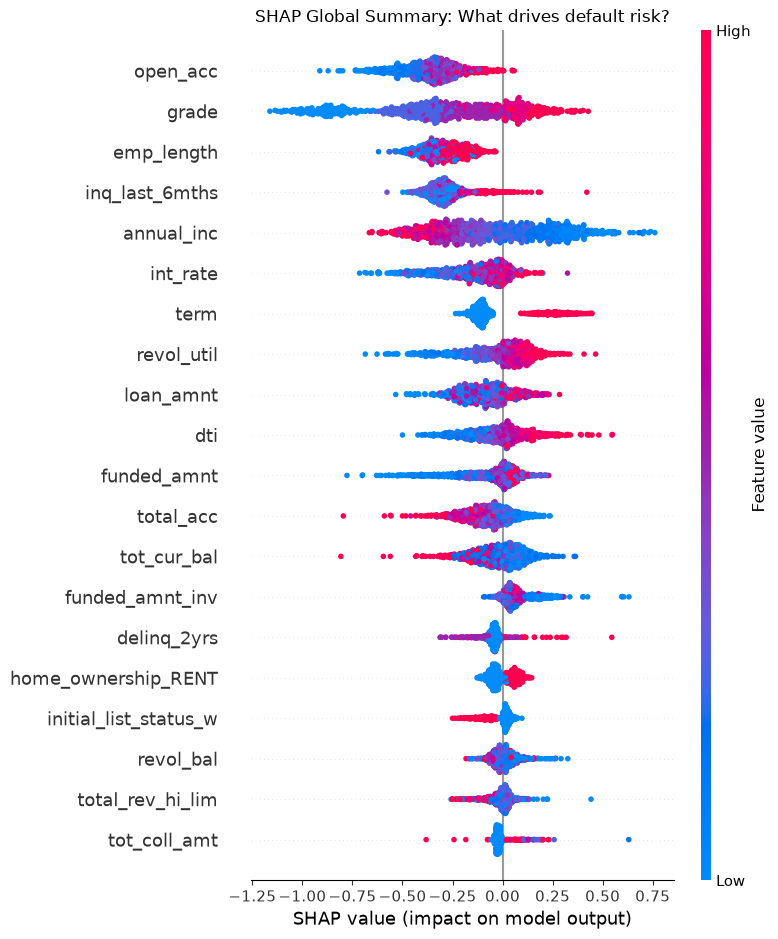


Generating SHAP Waterfall Plot for Applicant #0...


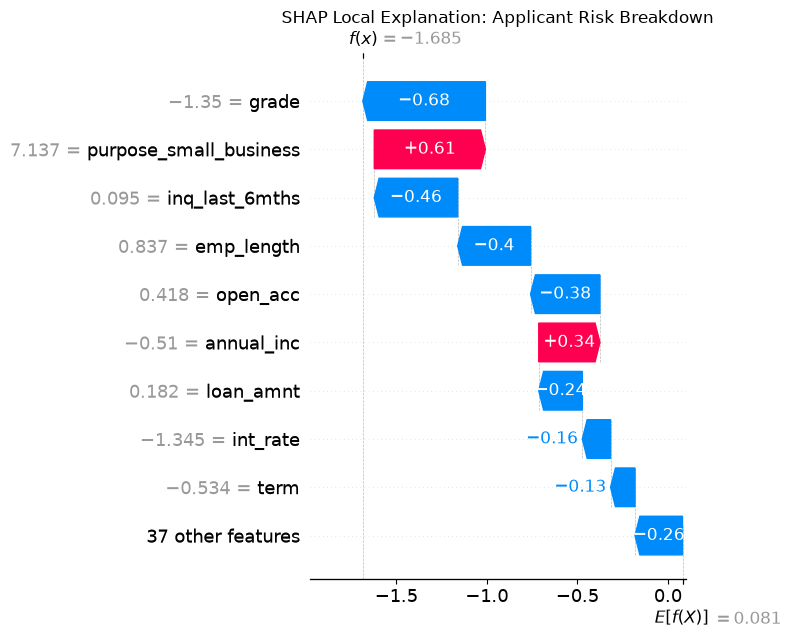


Applicant #0 raw XGBoost score/log-odds: -1.6850
Applicant #0 predicted default-risk probability: 15.64%
Decision threshold used in tuned model: 50%
Final decision using threshold: Good loan


In [ ]:
print("--- Running SHAP for XGBoost Model ---")

# 1. Initialize the SHAP Explainer using your trained XGBoost model
explainer = shap.TreeExplainer(xgb_model)

# PRO-TIP: SHAP takes a long time to run on 50,000 rows. 
# We will take a random sample of 1,000 test rows to generate the plots quickly!
X_test_sample = X_test_scaled.sample(n=1000, random_state=42)

# Calculate SHAP values for the sample
shap_values = explainer.shap_values(X_test_sample)


# CHART 1: GLOBAL TRANSPARENCY (The Bank's Policy)
print("\nGenerating SHAP Summary Plot...")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_sample, show=False)
plt.title("SHAP Global Summary: What drives default risk?")
plt.tight_layout()
plt.show()

# CHART 2: LOCAL TRANSPARENCY (Explaining a Single Applicant)
print("\nGenerating SHAP Waterfall Plot for Applicant #0...")
explanation = shap.Explanation(
    values=shap_values[0], 
    base_values=explainer.expected_value, 
    data=X_test_sample.iloc[0].values, 
    feature_names=X_test_sample.columns
)

plt.figure(figsize=(10, 6))
shap.plots.waterfall(explanation, show=False)
plt.title("SHAP Local Explanation: Applicant Risk Breakdown")
plt.tight_layout()
plt.show()

raw_score = explainer.expected_value + shap_values[0].sum()
risk_probability = expit(raw_score)

print(f"\nApplicant #0 raw XGBoost score/log-odds: {raw_score:.4f}")
print(f"Applicant #0 predicted default-risk probability: {risk_probability:.2%}")
print(f"Decision threshold used in tuned model: 50%")
print(f"Final decision using threshold: {'Bad loan / default risk' if risk_probability >= 50 else 'Good loan'}")


# Training Model 3b: XGBoost (After modifying the custom decision threshold of 30%)

In [ ]:
# ---- Part A: 5-Fold Cross-Validation (scaler -> SMOTE -> model -> custom threshold) ----

print("--- Training TUNED Model #3b: XGBoost (Banker's Penalty + 30% threshold) ---")
print("\n[CV] Running 5-Fold Stratified CV for TUNED XGBoost...")

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_metrics_3b = {'accuracy': [], 'precision': [], 'recall': [], 'f1': [], 'roc_auc': []}

custom_threshold = 0.30
feature_cols = X_train.columns

for fold_no, (train_idx, val_idx) in enumerate(cv_strategy.split(X_train, y_train), start=1):
    X_tr_cv, X_val_cv = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr_cv, y_val_cv = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # Compute the class-weight ratio BEFORE SMOTE to preserve the real imbalance information.
    ratio_cv = float(np.sum(y_tr_cv == 0)) / np.sum(y_tr_cv == 1)

    # Fit scaler only on the fold's training data to avoid validation leakage.
    sc = StandardScaler()
    X_tr_sc = pd.DataFrame(sc.fit_transform(X_tr_cv), columns=feature_cols)
    X_val_sc = pd.DataFrame(sc.transform(X_val_cv), columns=feature_cols)

    # Apply SMOTE only on the fold's training data.
    sm = SMOTE(random_state=42)
    X_tr_bal, y_tr_bal = sm.fit_resample(X_tr_sc, y_tr_cv)

    xgb_cv = XGBClassifier(
        random_state=42,
        n_jobs=-1,
        scale_pos_weight=ratio_cv,  # Consistent Banker's Penalty
        max_depth=4,
        learning_rate=0.1,
        n_estimators=200,
        eval_metric='logloss'
    )
    xgb_cv.fit(X_tr_bal, y_tr_bal)

    y_proba_cv = xgb_cv.predict_proba(X_val_sc)[:, 1]
    y_pred_cv = (y_proba_cv >= custom_threshold).astype(int)

    cv_metrics_3b['accuracy'].append(accuracy_score(y_val_cv, y_pred_cv))
    cv_metrics_3b['precision'].append(precision_score(y_val_cv, y_pred_cv, zero_division=0))
    cv_metrics_3b['recall'].append(recall_score(y_val_cv, y_pred_cv, zero_division=0))
    cv_metrics_3b['f1'].append(f1_score(y_val_cv, y_pred_cv, zero_division=0))
    cv_metrics_3b['roc_auc'].append(roc_auc_score(y_val_cv, y_proba_cv))

print("\n5-Fold CV Results (mean ± std across 5 folds):")
for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    scores = np.array(cv_metrics_3b[metric])
    print(f"  {metric:>10}: {scores.mean()*100:.2f}% ± {scores.std()*100:.2f}%")


--- Training TUNED Model #3b: XGBoost (After modifying the custom decision threshold of 30%)---

[CV] Running 5-Fold Stratified CV for TUNED XGBoost (with 30% threshold)...

  5-Fold CV Results (mean ± std across 5 folds):
  Accuracy  : 71.99%  ±  0.21%
  Precision : 33.58%  ±  0.57%
  Recall    : 50.01%  ±  0.96%
  F1-Score  : 40.18%  ±  0.68%
  ROC-AUC   : 70.22%  ±  0.45%


In [ ]:
# ---- Part B: 30-Seed Robustness Check (split -> scale -> SMOTE -> train -> test, repeated) ----

print("[Multi-Seed] Running 30 different random seeds for TUNED XGBoost...")

seed_results_3b = {'accuracy': [], 'precision': [], 'recall': [], 'f1': [], 'roc_auc': []}
custom_threshold = 0.30

for seed in range(30):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=seed, stratify=y
    )

    # Compute the class-weight ratio BEFORE SMOTE to preserve the real imbalance information.
    ratio_seed = float(np.sum(y_tr == 0)) / np.sum(y_tr == 1)

    sc = StandardScaler()
    X_tr_sc = pd.DataFrame(sc.fit_transform(X_tr), columns=X.columns)
    X_te_sc = pd.DataFrame(sc.transform(X_te), columns=X.columns)

    sm = SMOTE(random_state=seed)
    X_tr_bal, y_tr_bal = sm.fit_resample(X_tr_sc, y_tr)

    xgb_seed = XGBClassifier(
        random_state=seed,
        n_jobs=-1,
        scale_pos_weight=ratio_seed,  # Consistent Banker's Penalty
        max_depth=4,
        learning_rate=0.1,
        n_estimators=200,
        eval_metric='logloss'
    )
    xgb_seed.fit(X_tr_bal, y_tr_bal)

    y_proba_s = xgb_seed.predict_proba(X_te_sc)[:, 1]
    y_pred_s = (y_proba_s >= custom_threshold).astype(int)

    seed_results_3b['accuracy'].append(accuracy_score(y_te, y_pred_s))
    seed_results_3b['precision'].append(precision_score(y_te, y_pred_s, zero_division=0))
    seed_results_3b['recall'].append(recall_score(y_te, y_pred_s, zero_division=0))
    seed_results_3b['f1'].append(f1_score(y_te, y_pred_s, zero_division=0))
    seed_results_3b['roc_auc'].append(roc_auc_score(y_te, y_proba_s))

    if (seed + 1) % 10 == 0:
        print(f"  ... completed {seed + 1}/30 seeds")

print("\n30-Seed Results (mean ± std across 30 random splits):")
for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    scores = np.array(seed_results_3b[metric])
    print(f"  {metric:>10}: {scores.mean()*100:.2f}% ± {scores.std()*100:.2f}%")

[Multi-Seed] Running 30 different random seeds for TUNED XGBoost...
  ... completed 10/30 seeds

  Multi-Seed Results (mean ± std across 30 random splits):
  Accuracy  : 72.24%  ±  0.26%
  Precision : 32.95%  ±  0.27%
  Recall    : 49.25%  ±  0.43%
  F1-Score  : 39.48%  ±  0.21%
  ROC-AUC   : 70.15%  ±  0.18%
  ... completed 20/30 seeds

  Multi-Seed Results (mean ± std across 30 random splits):
  Accuracy  : 72.21%  ±  0.27%
  Precision : 32.90%  ±  0.31%
  Recall    : 49.21%  ±  0.53%
  F1-Score  : 39.43%  ±  0.30%
  ROC-AUC   : 70.10%  ±  0.24%
  ... completed 30/30 seeds

  Multi-Seed Results (mean ± std across 30 random splits):
  Accuracy  : 72.19%  ±  0.28%
  Precision : 32.88%  ±  0.31%
  Recall    : 49.26%  ±  0.48%
  F1-Score  : 39.44%  ±  0.27%
  ROC-AUC   : 70.09%  ±  0.24%


In [ ]:
# ---- Part C: Final Model (fit on the full training set) ----

ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)
print(f"Banker's Penalty (scale_pos_weight) calculated before SMOTE: {ratio:.2f}")

custom_threshold = 0.30

# 1. Initialize the Tuned Model
xgb_tuned = XGBClassifier(
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=ratio,  # Consistent Banker's Penalty
    max_depth=4,             # Prevents overfitting
    learning_rate=0.1,       # Learns slower and more steadily
    n_estimators=200,
    eval_metric='logloss'
)

# 2. Train the model on the already-created SMOTE-balanced training set
xgb_tuned.fit(X_train_balanced, y_train_balanced)

# 3. Make Predictions (probabilities first)
y_pred_proba_xgb = xgb_tuned.predict_proba(X_test_scaled)[:, 1]

# 4. Custom decision threshold
# Instead of 50%, we flag a loan as 'Bad / Default Risk' (1) if risk is >= 30%.
y_pred_custom = (y_pred_proba_xgb >= custom_threshold).astype(int)

print("--- TUNED XGBOOST PERFORMANCE METRICS ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_custom)*100:.2f}%")
print(f"Precision: {precision_score(y_test, y_pred_custom, zero_division=0)*100:.2f}%")
print(f"Recall:    {recall_score(y_test, y_pred_custom, zero_division=0)*100:.2f}%")
print(f"F1-Score:  {f1_score(y_test, y_pred_custom, zero_division=0)*100:.2f}%")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_xgb)*100:.2f}%")

print("\n--- NEW CONFUSION MATRIX ---")
cm_tuned = confusion_matrix(y_test, y_pred_custom)
print(f"True Negatives  (Predicted Good, Actually Good): {cm_tuned[0][0]}")
print(f"False Positives (Predicted Bad,  Actually Good): {cm_tuned[0][1]} <- 'Lost Business'")
print(f"False Negatives (Predicted Good, Actually Bad):  {cm_tuned[1][0]} <- 'Financial Loss' (Should be lower!)")
print(f"True Positives  (Predicted Bad,  Actually Bad):  {cm_tuned[1][1]}")

print("\n--- DETAILED CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred_custom, zero_division=0))

# The black-box problem: built-in feature importance is useful but not enough for applicant-level explanation.
print("\n--- BUILT-IN FEATURE IMPORTANCE (The Problem) ---")
xgb_importance = pd.DataFrame({
    'Feature': X_train_balanced.columns,
    'Importance': xgb_tuned.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(xgb_importance.head(10))


--- TUNED XGBOOST PERFORMANCE METRICS ---
Accuracy:  32.17%
Precision: 20.76%
Recall:    95.49%
F1-Score:  34.11%
ROC-AUC:   70.09%

--- NEW CONFUSION MATRIX ---
True Negatives  (Predicted Good, Actually Good): 7514
False Positives (Predicted Bad,  Actually Good): 34428 <- 'Lost Business'
False Negatives (Predicted Good, Actually Bad):  426 <- 'Financial Loss' (Should be lower!)
True Positives  (Predicted Bad,  Actually Bad):  9020

--- DETAILED CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.95      0.18      0.30     41942
           1       0.21      0.95      0.34      9446

    accuracy                           0.32     51388
   macro avg       0.58      0.57      0.32     51388
weighted avg       0.81      0.32      0.31     51388


--- BUILT-IN FEATURE IMPORTANCE (The Problem) ---
           Feature  Importance
11  inq_last_6mths    0.163140
6            grade    0.118502
7       emp_length    0.101789
12        open_acc    

--- Running SHAP for the TUNED XGBoost Model ---

Generating Global Summary Plot...


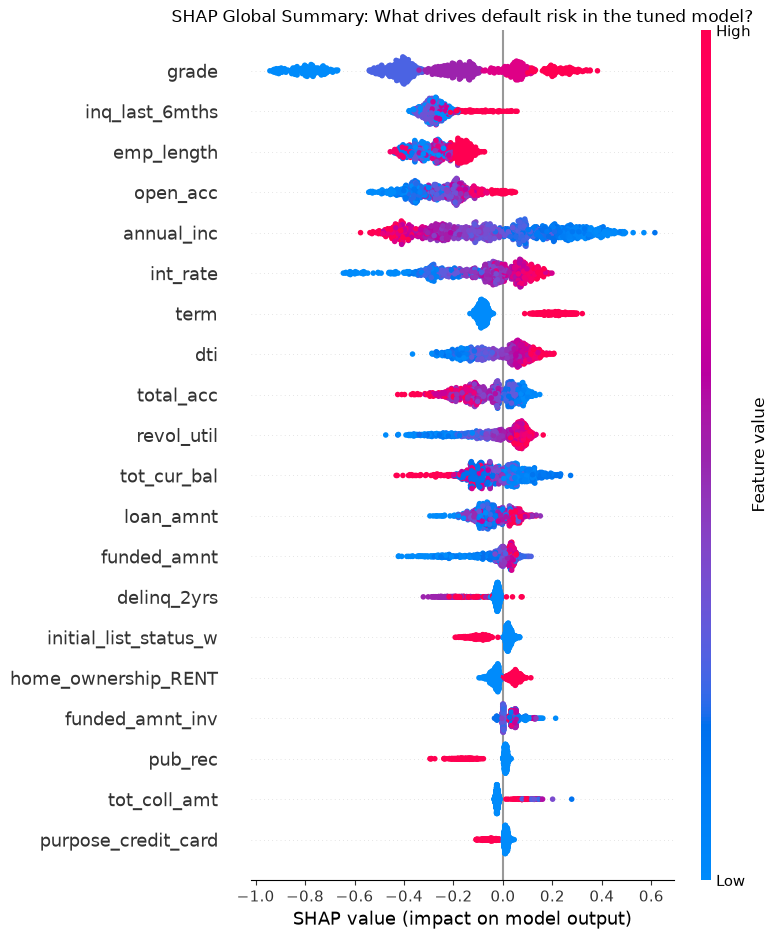


Generating Local Waterfall Plot for Applicant #0...


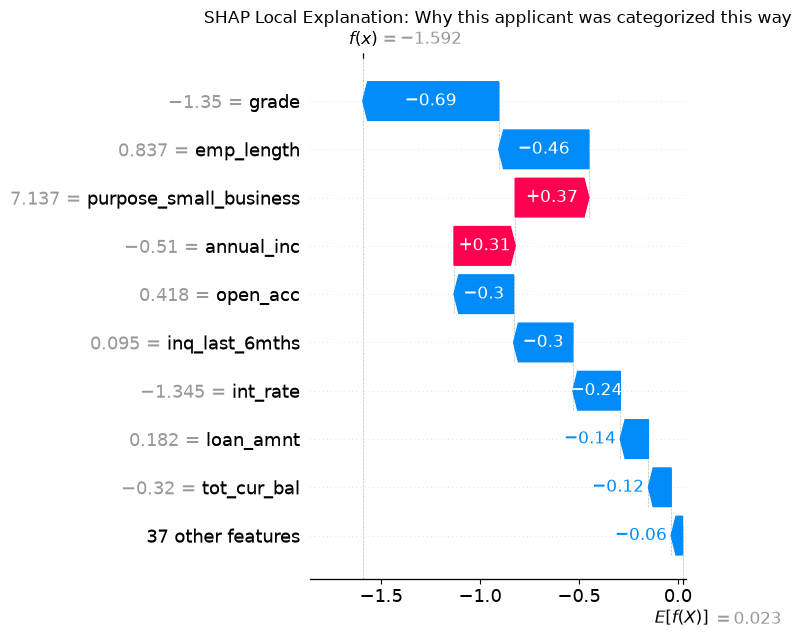


Applicant #0 raw XGBoost score/log-odds: -1.5925
Applicant #0 predicted default-risk probability: 16.90%
Decision threshold used in tuned model: 30%
Final decision using threshold: Good loan


In [ ]:
print("--- Running SHAP for the TUNED XGBoost Model ---")

explainer = shap.TreeExplainer(
    xgb_tuned,
    feature_perturbation="tree_path_dependent",
    model_output="raw"
)

# Take a sample for faster performance.
sample_size = min(1000, len(X_test_scaled))
X_test_sample = X_test_scaled.sample(n=sample_size, random_state=42)

# Calculate SHAP values for the sample
shap_values = explainer.shap_values(X_test_sample, check_additivity=False)

# Safety handling in case SHAP returns a list for class outputs
expected_value = explainer.expected_value
if isinstance(shap_values, list):
    shap_values = shap_values[1]
    expected_value = expected_value[1]

expected_value = float(np.array(expected_value).ravel()[0])

# CHART 1: GLOBAL SUMMARY PLOT
print("\nGenerating Global Summary Plot...")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_sample, show=False)
plt.title("SHAP Global Summary: What drives default risk in the tuned model?")
plt.tight_layout()
plt.show()

# CHART 2: LOCAL WATERFALL PLOT
print("\nGenerating Local Waterfall Plot for Applicant #0...")

explanation = shap.Explanation(
    values=shap_values[0],
    base_values=expected_value,
    data=X_test_sample.iloc[0].values,
    feature_names=X_test_sample.columns
)

shap.plots.waterfall(explanation, show=False)
plt.title("SHAP Local Explanation: Why this applicant was categorized this way")
plt.tight_layout()
plt.show()

raw_score = expected_value + shap_values[0].sum()
risk_probability = expit(raw_score)

print(f"\nApplicant #0 raw XGBoost score/log-odds: {raw_score:.4f}")
print(f"Applicant #0 predicted default-risk probability: {risk_probability:.2%}")
print(f"Decision threshold used in tuned model: {custom_threshold:.0%}")
print(f"Final decision using threshold: {'Bad loan / default risk' if risk_probability >= custom_threshold else 'Good loan'}")

In [ ]:
print("--- Statistical Significance Testing (Wilcoxon Signed-Rank Test) ---")
print("Comparing the Recall of Baseline Logistic Regression vs. Tuned XGBoost\n")

# Extract the 30 recall scores from the multi-seed runs.
baseline_recall = np.array(seed_metrics['recall'])
tuned_xgb_recall = np.array(seed_results_3b['recall'])

# The Wilcoxon Signed-Rank Test checks whether the paired recall scores differ significantly.
statistic, p_value = wilcoxon(baseline_recall, tuned_xgb_recall)

# Direction of difference matters: p-value only tells significance, not whether it improved.
recall_diff = tuned_xgb_recall - baseline_recall
mean_diff = recall_diff.mean()

print(f"Baseline Logistic Regression Recall: {baseline_recall.mean()*100:.2f}% ± {baseline_recall.std()*100:.2f}%")
print(f"Tuned XGBoost Recall:               {tuned_xgb_recall.mean()*100:.2f}% ± {tuned_xgb_recall.std()*100:.2f}%")
print(f"Mean Recall Difference:             {mean_diff*100:.2f}%")
print(f"Wilcoxon Statistic:                 {statistic}")
print(f"P-Value:                            {p_value:.6f}\n")

alpha = 0.05

if p_value < alpha and mean_diff > 0:
    print("Conclusion: The P-Value is less than 0.05.")
    print("Result: REJECT the null hypothesis.")
    print("Business Meaning: Tuned XGBoost has a statistically significant RECALL IMPROVEMENT over Logistic Regression.")
elif p_value < alpha and mean_diff < 0:
    print("Conclusion: The P-Value is less than 0.05.")
    print("Result: REJECT the null hypothesis.")
    print("Business Meaning: Tuned XGBoost has a statistically significant RECALL DECREASE compared with Logistic Regression.")
else:
    print("Conclusion: The P-Value is greater than or equal to 0.05.")
    print("Result: FAIL TO REJECT the null hypothesis.")
    print("Business Meaning: The recall difference is not statistically significant.")


--- Statistical Significance Testing (Wilcoxon Signed-Rank Test) ---
Comparing the Recall of our Baseline (Logistic Regression) vs. Tuned XGBoost

Wilcoxon Statistic: 0.0
P-Value: 0.000000

Conclusion: The P-Value is less than 0.05.
Result: REJECT the null hypothesis.
Business Meaning: The improvement in Recall by the Tuned XGBoost model is STATISTICALLY SIGNIFICANT, not due to random chance.


# All 3 Models — Robustness Summary

In [ ]:
print("--- ROBUSTNESS SUMMARY: All 4 Models (30-Seed Average) ---")

robust_summary = pd.DataFrame({
    'Metric'   : ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Log. Reg.': [np.mean(seed_metrics[k]) for k in ['accuracy','precision','recall','f1','roc_auc']],
    'Rand. Forest': [np.mean(seed_results_rf[k]) for k in ['accuracy','precision','recall','f1','roc_auc']],
    'XGBoost'  : [np.mean(seed_results_xgb[k]) for k in ['accuracy','precision','recall','f1','roc_auc']],
    'Tuned XGBoost'  : [np.mean(seed_results_3b[k]) for k in ['accuracy','precision','recall','f1','roc_auc']],
}).set_index('Metric').round(4)

print(robust_summary)

--- ROBUSTNESS SUMMARY: All 3 Models (30-Seed Average) ---
           Log. Reg.  Rand. Forest  XGBoost  Tuned XGBoost
Metric                                                    
Accuracy      0.6468        0.7935   0.8150         0.7219
Precision     0.2926        0.3875   0.4802         0.3288
Recall        0.6497        0.2123   0.0802         0.4926
F1-Score      0.4035        0.2743   0.1374         0.3944
ROC-AUC       0.7021        0.6906   0.7025         0.7009
